<a href="https://colab.research.google.com/github/hanaship-it/Wyniki-student-w/blob/main/programowanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza wpływu czynników edukacyjnych i pozaedukacyjnych na wyniki studentów

**1. Cel analizy:**
Celem projektu jest zbudowanie modelu uczenia maszynowego zdolnego do przewidywania ostatecznego wskaźnika wydajności studenta (zmienna: `Performance Index`) oceny jego stylu nauki i życia.

**2. Opis danych:**
Zbiór pochodzi z platformy Kaggle ("Student Performance Multiple Linear Regression"). Zawiera informacje o 10 000 studentów. Ma 5 zmiennych objaśniających: czas poświęcony na naukę, wcześniejsze wyniki w nauce, udział w zajęciach pozalekcyjnych, ilość snu oraz liczba rozwiązanych próbnych arkuszy egzaminacyjnych. Zmienną objaśnianą jest wskaźnik wyniku (`Performance Index`).
Zadanie ma charakter regresji czyli przewidujemy wartość ciągłą.

**3. Hipotezy badawcze:**
* **Hipoteza 1:** Czas nauki (`Hours Studied`) i wcześniejsze wyniki (`Previous Scores`) będą miały największy, bezpośredni wpływ na ostateczny wskaźnik wydajności.
* **Hipoteza 2:** Odpowiednia ilość snu (`Sleep Hours`) w średnim stopniu wspomaga ostateczny wynik.

In [14]:
import kagglehub

# 1. Pobieramy plik z Kaggle i zapisujemy ścieżkę do zmiennej 'path'
path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")


Using Colab cache for faster access to the 'student-performance-multiple-linear-regression' dataset.


In [15]:
import pandas as pd

# 2. Wczytujemy do tabeli DataFrame
df = pd.read_csv('Student_Performance.csv')   # przypisujemy plik tekstowy z danymi do zmiennej df

df.head()      # Wyświetla 5 pierwszych wierszy tabeli

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB
None


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [16]:
# Usunięcie duplikatów

df = df.drop_duplicates()
print(f"Liczba wierszy po usunięciu duplikatów: {df.shape[0]}")

# Pokazuje tuple po czyszczeniu (shape: wiersze i kolumny, [0] pierwsza wartość, liczba wierszy)

Liczba wierszy po usunięciu duplikatów: 9873


In [18]:
# Podstawowe informacje: typy danych, czy są puste wartości#
print("Informacje o danych")
df.info()                    # sprawdza ile mamy wierszy, kolumn, jakiego są typu (liczby czy tekst) i czy brakuje jakichś danych


Informacje o danych
<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   object 
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 539.9+ KB


In [19]:
# Statystyki: średnia, min, max, odchylenie

display(df.describe())  # Podsumowuje matematycznie, pokazuje średnią, wartość najmniejszą i największą dla każdej kolumny

Statystyki opisowe


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000
mean,4.992100,69.441102,6.531652,4.583004,55.216651
std,2.589081,17.325601,1.697683,2.867202,19.208570
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


### Co mówią nam podstawowe informacje o danych

Zanim zaczniemy budować modele, musimy poznać nasze dane. Z funkcji `info()` oraz `describe()` możemy wyciągnąć kilka bardzo ważnych wniosków na start:

1. Dane są kompletne: Mamy dokładnie 9873 wierszy i w żadnej kolumnie nie brakuje danych (widzimy "9873 non-null").
2. Nasz cel (Performance Index): Średni wynik studenta to około 55 punktów. Najsłabszy student zdobył 10 punktów, a najlepszy 100. Mamy przekrój ocen.
3. Średnio studenci spędzają na nauce 5 godzin i śpią około 6,5 godziny.
 Wcześniejsze oceny (`Previous Scores`) są bardzo zróżnicowane – od 40 do 99 punktów.
4. Brak błędów w danych: Nie widać tu żadnych "dziwnych" wartości, np. ujemnych godzin snu albo ocen powyżej 100. .


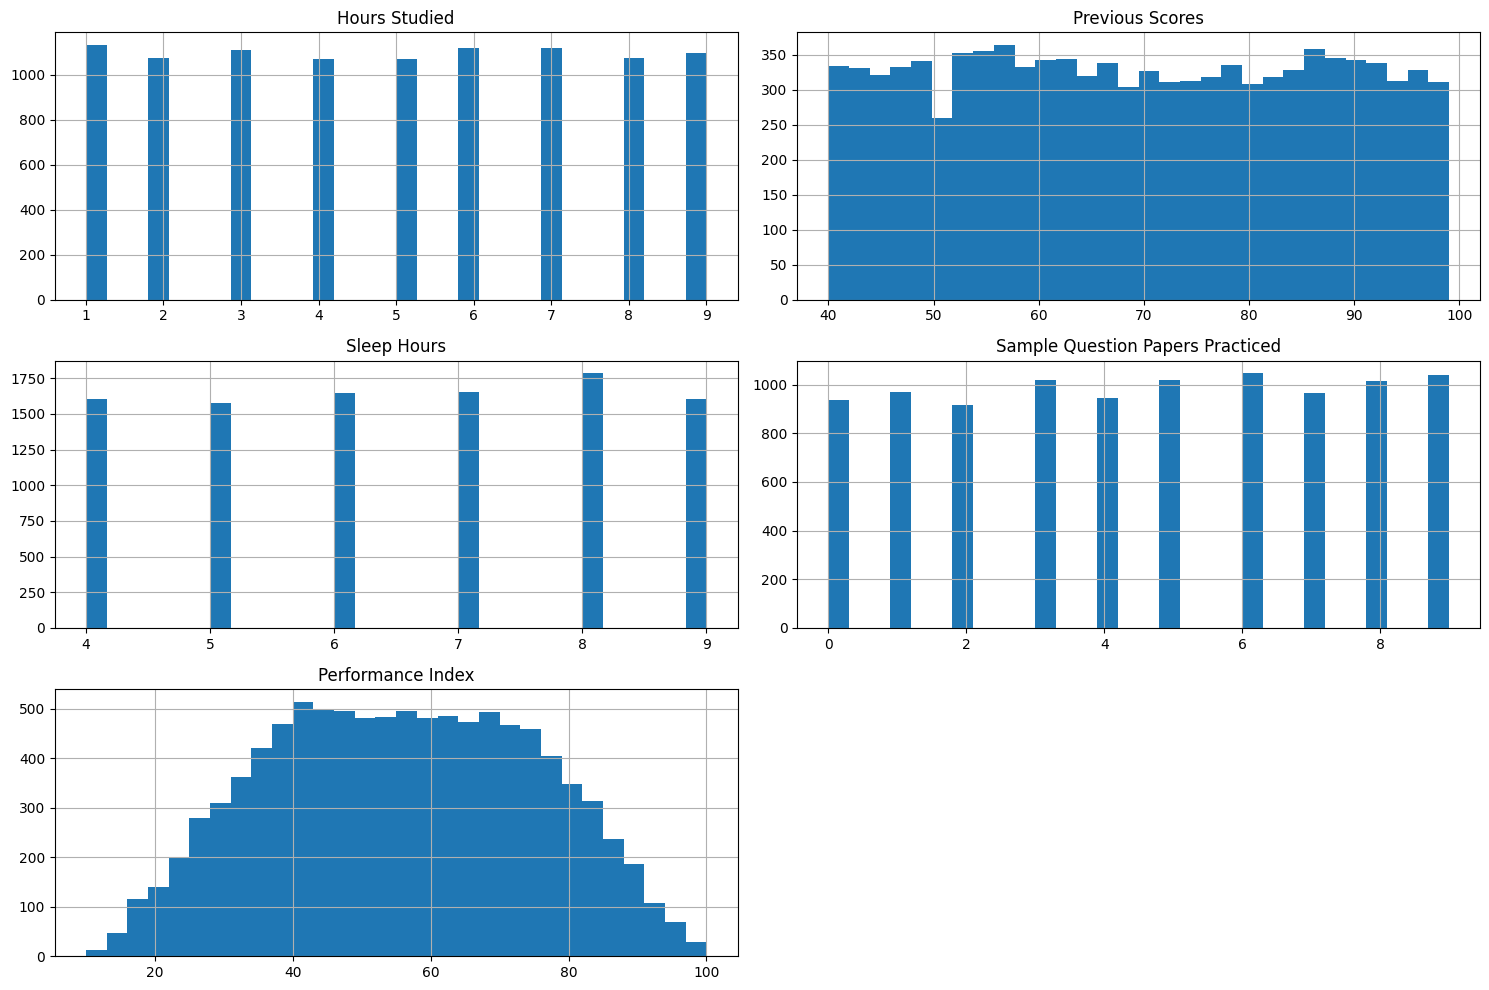

In [20]:
# Rysowanie histogramów dla wszystkich kolumn numerycznych
import matplotlib.pyplot as plt     # biblioteka do wizualizacji danych. model do szybkiego tworzenia wykresów

df.hist(bins=30, figsize=(15, 10))  #dane z każdej kolumny zostaną podzielone na 30 (oś X), niemutowalna lista elementów: (szerokość, wysokość)
plt.tight_layout()                  # zapobiega nakładaniu się wykresów na siebie
plt.show()                          # konfiguruje i wyswietla

### Wnioski z histogramów

Wykresy słupkowe pokazują nam, jak rozkładają się wartości w poszczególnych kolumnach:

1. Wykresy dla godzin nauki (`Hours Studied`) i snu (`Sleep Hours`) są dość płaskie (przypominają prostokąt) w zbiorze jest podobna liczba osób, które uczą się mało, średnio i dużo, jest zbalansowany.
2. Wynik końcowy (Performance Index): Ten wykres wygląda jak górka. Najwięcej studentów osiąga średnie wyniki (ok. 50-60 punktów), a skrajnie złych i skrajnie dobrych ocen jest najmniej.

### Analiza Korelacji Heatmap
Za pomocą mapy cieplnej (heatmap) sprawdzimy zależności liniowe pomiędzy poszczególnymi zmiennymi liczbowymi a naszym celem (`Performance Index`).


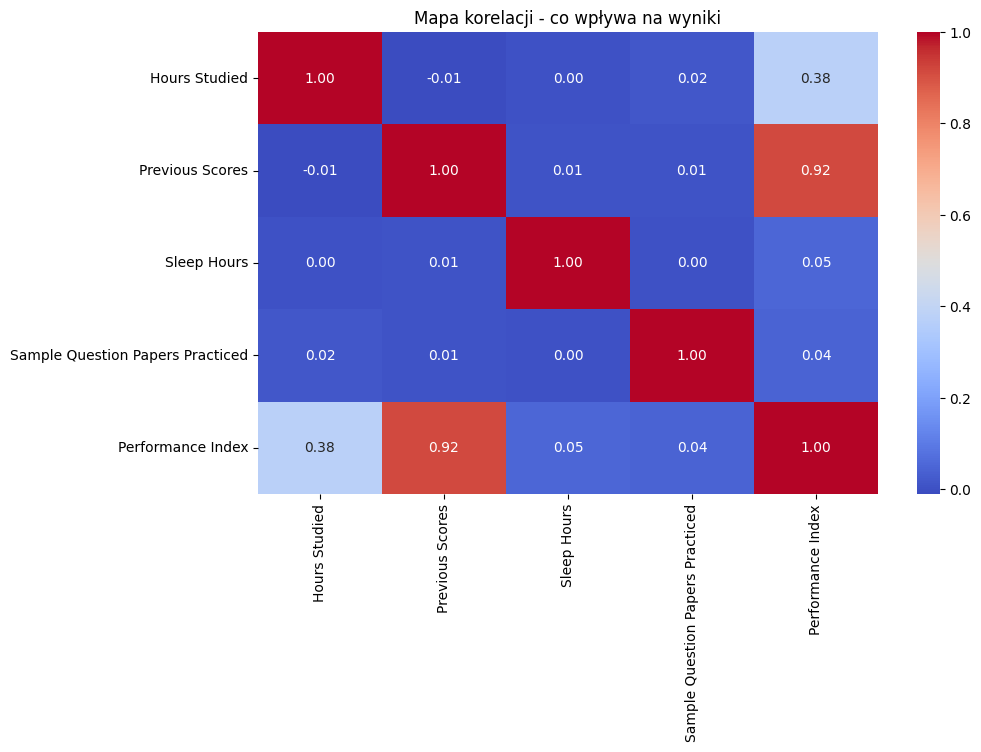

In [21]:
import seaborn as sns                            #automatyzuje tworzenie złożonych wykresów statystycznych
import matplotlib.pyplot as plt

# Wykres korelacji dla danych liczbowych
plt.figure(figsize=(10, 6))                              # nowe okno wykresu o szerokości 10 i wysokości 6 cali
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

# Zwraca nową tabelę z wynikami od -1.0 do 1.0, wyłącznie kolumny z typami numerycznymi (int/float), a zignorowanie tekstowych (stringi)
# Argument mapujący wartości liczbowe na gradient kolorów, formatowanie stringów (2 miejsce po przecinku, float)

plt.title("Mapa korelacji - co wpływa na wyniki")
plt.show()

### Wnioski z mapy korelacji

Pokazuje w skali od -1 do 1, jak mocno poszczególne rzeczy (jak sen czy nauka) wiążą się z wynikiem końcowym (`Performance Index`). Im wynik bliżej 1, tym silniejszy wpływ.

1. Zależność między `Previous Scores` a końcowym wynikiem wynosi aż 0.92!
Oznacza to, że studenci, którzy wcześniej radzili sobie dobrze, prawie zawsze radzą sobie dobrze na końcu.
2. Godziny spędzone na nauce (`Hours Studied`) też mają wyraźny, pozytywny wpływ na wynik.
3. Korelacje dla godzin snu (0.05) i rozwiązanych testów (0.04) są bliskie zeru. W tym zbiorze danych, to ile ktoś spał, zupełnie nie przekłada się na jego ostateczną ocenę.

Możemy przypuszczać, że najprostsze modele z poradzą sobie z przewidywaniem, bo zależność opiera się głównie na jednej, silnej zmiennej (Previous Scores).



## Przygotowanie danych i implementacja metod

Aby modele mogły skutecznie się uczyć, musimy odpowiednio przygotować dane (preprocessing):

1. **Zamiana tekstu na liczby:** Nasz zbiór jest już prawie w całości liczbowy. Jedyną kolumną tekstową jest `Extracurricular Activities` (Yes/No) zamienimy "Yes" na 1, a "No" na 0.
2. **Podział zbioru (Train/Test Split):** Dzielimy dane w proporcji 80/20. 80% posłuży do nauki i testów wewnętrznych. 20% to nasz zbiór testowy zamykamy go i otworzymy tylko raz, na samym końcu.

In [22]:
# Zamiana wartości tekstowych 'Yes'/'No' na liczby 1/0
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({"Yes": 1, "No": 0})   # Odwołujemy się do konkretnej kolumny i nadpisujemy

X = df.drop("Performance Index", axis=1)              # przypisujemy całą tabelę poza wynikiem końcowym, szukać w oś Y
y = df["Performance Index"]

from sklearn.model_selection import train_test_split  # biblioteka do uczenia maszynowego, przyjmuje  macierze danych i losowo rozdziela na zbiór uczący i testowy, według proporcji.

# Zostawiamy 20% danych do ostatecznego testu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)      #ten sam ciąg "losowych" liczb

print(f"Zbiór treningowy: {X_train.shape[0]} wierszy")
print(f"Zbiór testowy: {X_test.shape[0]} wierszy")

Zbiór treningowy: 7898 wierszy
Zbiór testowy: 1975 wierszy


## Wstępna ocena modeli (Walidacja Krzyżowa)

Przetestujemy 3 różne algorytmy (Regresję Liniową, Drzewo Decyzyjne i Las Losowy) na samych danych treningowych, używając walidacji krzyżowej (cross-validation).

Dodatkowo, każdy model zostanie wyposażony w `StandardScaler`, który znormalizuje nasze dane (co jest szczególnie ważne dla poprawnego działania wielu algorytmów).

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import pandas as pd

# Definiujemy słownik (klucze: wartości). każdy model ma teraz swój własny StandardScaler
models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Decision Tree": Pipeline([("scaler", StandardScaler()), ("model", DecisionTreeRegressor(random_state=42))]),
    "Random Forest": Pipeline([("scaler", StandardScaler()), ("model", RandomForestRegressor(random_state=42))])
}
# Pierwszy krok. Każdy model dostaje własny, obiekt skalera, który ustandaryzuje dane, zanim trafią do algorytmu, Drugi krok właściwy algorytm, który będzie się uczył.

cv_results = []  # pusta lista 'notatnik na wyniki'

print("Rozpoczynam walidację krzyżową na danych treningowych")
for name, model in models.items():


    scores = cross_val_score(model, X_train, y_train, scoring="neg_root_mean_squared_error", cv=5)
                  # funkcję z biblioteki scikit-learn, komenda oceniająca model miarą RMSE, wynik podaj z minusem
                  # cv=5 model uczy się i sprawdza na 5 różnych wycinkach danych treningowych

    cv_results.append({                               #nowy element na koniec listy
        "Model": name,
        "Średnie RMSE (Train)": -scores.mean(),       # pięć ocen z minusem, .mean() oblicza średnią arytmetyczną, pozbyć się minusa stawiamy operator -
        "Odchylenie RMSE": scores.std()               # liczy odchylenie standardowe
    })


# Wyświetlamy tabelkę z wynikami metody sortującej, wskazujemy według której kolumny tabela ma się posortować
df_cv_results = pd.DataFrame(cv_results).sort_values(by="Średnie RMSE (Train)")
display(df_cv_results)

Rozpoczynam walidację krzyżową na danych treningowych


,Model,Średnie RMSE (Train),Odchylenie RMSE
0,Linear Regression,2.037286,0.022611
2,Random Forest,2.352005,0.060505
1,Decision Tree,3.096908,0.100253


### Wnioski z walidacji krzyżowej (Wybór najlepszego algorytmu)

Walidacja krzyżowa (Cross-Validation) pozwoliła nam sprawdzić 3 różne modele wyłącznie na danych treningowych, ucząc je i testując na 5 różnych fragmentach.

Z tabeli wyników jasno wynika, że najlepiej radzi sobie Regresja Liniowa. Algorytmy oparte na drzewach (Decision Tree i Random Forest) wykazują wyższy błąd bazowy. Ponieważ zależy nam na wybraniu jednego, najlepszego kandydata do testu ostatecznego, czyli Regresja Liniowa.

### Próba ulepszenia (GridSearchCV)

Walidacja krzyżowa pokazała nam, że Regresja Liniowa radzi sobie świetnie. Sprawdźmy jednak, czy zaawansowane strojenie hiperparametrów dla (Random Forest) pozwoli mu pobić wynik prostej regresji. Użyjemy do tego `GridSearchCV`, który automatycznie przetestuje kombinacje liczby drzew i ich głębokości, aby odnaleźć optymalny model.

In [24]:
from sklearn.model_selection import GridSearchCV      # siatka(opcje), szukanie, Cross-Validation (walidacja krzyżowa)

rf_pipeline = Pipeline([             # tworzymy nazwe zmiennej, tworzymy liste
    ("scaler", StandardScaler()),          # skalujemy dane
    ("model", RandomForestRegressor(random_state=42))
])

# Dodajemy szersze ramy dla parametrów
param_grid = {                               # Słownik, nazwy parametrów: listy wartości, które algorytm ma dla nich przetestować.
    'model__n_estimators': [100, 200, 300],  # nie dotyczą skalera, tylko pracownika, który ma plakietkę 'model. __Liczba drzew
    'model__max_depth': [5, 10, 20, None],   # Ile "poziomów" decyzji (pytań "tak/nie") może zadać jedno drzewo,
    'model__min_samples_split': [2, 5, 10],  # Minimalna liczba studentów (próbek), jaka musi znaleźć się w danym punkcie decyzyjnym
    'model__min_samples_leaf': [1, 2, 4].    # Minimalna liczba studentów, jaka musi zostać na samym końcu gałęzi (w liściu)
}

print("Szukam najlepszych parametrów dla Random Forest")
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)  # słownik z opcjami, walidację krzyżową 3 podziały, Wskazujemy na metrykę RMSE, liczyć te modele równolegle
grid_search.fit(X_train, y_train)           # zaczyna i bierze pytania i odpowiedzi, siłowo testuje każdą kombinację

print(f"Najlepsze znalezione parametry: {grid_search.best_params_}")
print(f"Błąd RMSE (walidacja GridSearch): {-grid_search.best_score_:.2f}")

Szukam najlepszych parametrów dla Random Forest
Najlepsze znalezione parametry: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Błąd RMSE (walidacja GridSearch): 2.25


### Wnioski ze strojenia parametrów Lasu Losowego

Mimo zastosowania `GridSearchCV` i sprawdzenia wielu kombinacji hiperparametrów (model wybrał m.in. 300 drzew i maksymalną głębokość 10), osiągnął błąd RMSE na poziomie 2.25 punktu.

Wynik ten potwierdza nasze wcześniejsze przypuszczenia: w przypadku tych zbioru danych to Regresja Liniowa pozostaje lepsza.

## Ostateczna ewaluacja zwycięskiego modelu na zbiorze testowym

Skoro nasze testy treningowe wykazały, że **Regresja Liniowa** jest najdokładniejsza, wyciągamy z nasz nienaruszony zbiór testowy (`X_test`, `y_test`) i dokonujemy ostatecznej oceny tego algorytmu.

In [25]:
# Z biblioteki z działu metrics wyciągamy dwa wzory. do wyliczenia błędu, do wyliczenia dokładności
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("OSTATECZNY MODEL")

# Pobieramy zwycięski model ze słownika
final_model = models["Linear Regression"]

# Uczymy go na całości danych treningowych (80%)
final_model.fit(X_train, y_train)

# PROGNOZA NA ZBIORZE TESTOWYM (Tym, którego model nigdy wcześniej nie widział 20% tylko pytania)
y_pred_final = final_model.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))  # funkcja bierze klucz odpowiedzi 20%(y_test) i z odpowiedzi wymyślonye przez model, do kwadratu
final_r2 = r2_score(y_test, y_pred_final)                       # Wylicza współczynnik (R-kwadrat), Porównuje nasz model do najgłupszego możliwego modelu

print(f"Ostateczny błąd na zbiorze testowym (RMSE): {final_rmse:.2f} punktów")    # dwa miejsca po przecinku
print(f"Ostateczna dokładność (R2): {final_r2:.3f}")                             # trzy miejsca po

OSTATECZNY MODEL
Ostateczny błąd na zbiorze testowym (RMSE): 2.08 punktów
Ostateczna dokładność (R2): 0.988


## Końcowe wnioski i weryfikacja założeń (Podsumowanie)

1. **Wynik ostateczny:** Model osiągnął dokładność (R2) równą **0.988 (98.8%)** oraz błąd **RMSE rzędu 2.08 punktu**. Oznacza to, że nasz model przewiduje wynik studenta myląc się średnio o zaledwie ~2 punkty na 100 możliwych.
2. **Zwycięzcą okazała się Regresja Liniowa.** W trakcie walidacji krzyżowej i testowania, skomplikowane algorytmy (jak optymalizowany przez Grid Search Random Forest, który osiągnął błąd RMSE = 2.25) nie były skuteczniejsze od prostego modelu matematycznego.

### Weryfikacja hipotez badawczych:
* **Hipoteza 1 (Potwierdzona):** Czas nauki (`Hours Studied`) i wcześniejsze wyniki (`Previous Scores`) absolutnie zdominowały wpływ na ocenę końcową, co udowodniła mapa korelacji oraz doskonałe wyniki modelu liniowego.
* **Hipoteza 2 (Odrzucona):** Zakładaliśmy, że sen i zajęcia pozalekcyjne będą miały chociaż minimalny, widoczny wpływ. Okazało się jednak, że dla tego specyficznego zbioru danych, zmienne te są statystycznie nieistotne i nie wpływają zauważalnie na `Performance Index`.